# Lab 3

Authors: Khanh Do, Liam Ko

## Imports

In [1]:
## Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)  
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [2]:
## Data
## Function used to make the synthetic data
def make_synth_data(n_sig, n_noise):
    n = 400
    
    # Binary outcome (50-50 class distribution)
    np.random.seed(7)
    y = np.random.binomial(1, 0.5, n)

    # Create the signal features
    X_signal = np.zeros((n, n_sig))
    X_signal[y == 0] = np.random.normal(-1, 1, size=(sum(y == 0), n_sig))
    X_signal[y == 1] = np.random.normal(+1, 1, size=(sum(y == 1), n_sig))

    # Noise features
    X_noise = np.random.normal(0, 1, size=(n, n_noise))

    # Combine signal and noise features
    X = np.hstack([X_signal, X_noise])

    return X, y

## Make 3 versions of the synthetic data w/ increasing n_noise
X2, y2 = make_synth_data(2, 2)
X48, y48 = make_synth_data(2, 48)
X198, y198 = make_synth_data(2, 198)

### Read flattened version of MNIST
mnist = pd.read_csv("https://remiller1450.github.io/data/mnist_small.csv")

### Separate the target variable (label column)
label = mnist['label']
mnist = mnist.drop(['label'], axis=1)

### Convert to numpy array and reshape to 28 by 28
mnist_unflattened = mnist.to_numpy()
mnist_unflattened = mnist_unflattened.reshape(6000,28,28)

## Question 1

### Part A

In [3]:
from sklearn.model_selection import train_test_split
x198_train, x198_test, y198_train, y198_test = train_test_split(X198,y198,test_size=0.25,random_state=7)

### Part B

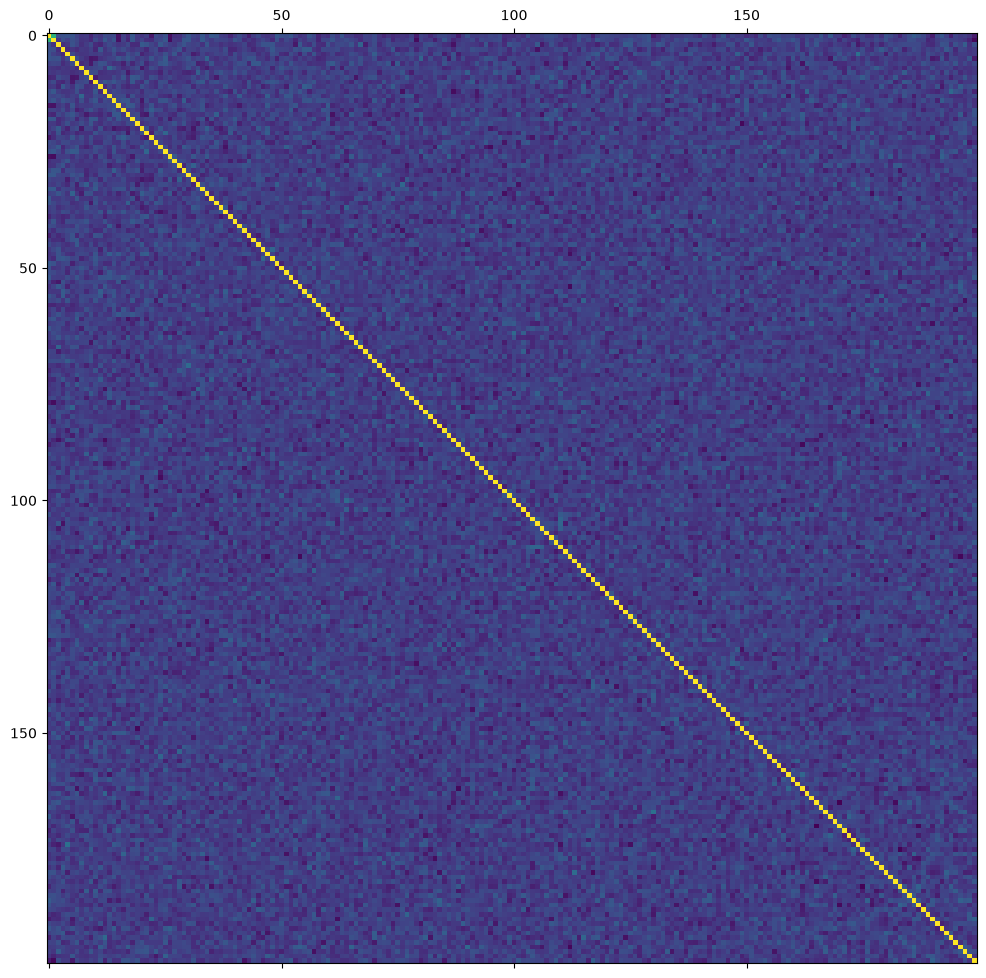

In [4]:
plt.matshow(pd.DataFrame(x198_train).corr())
plt.gcf().set_size_inches(12, 12)
plt.show()

### Part C

The corrplot shows that besides the diagonal line which is each feature correlating to itself, there is no correlation between different features. Thus, there won't be meaningful PCAs made and PCA won't improve KNN model much.

## Question 2

### Part A

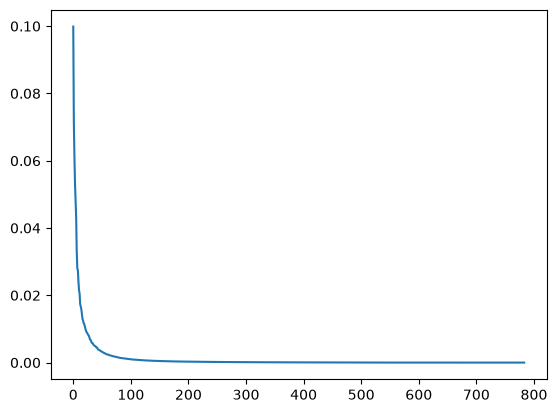

In [5]:
from sklearn.decomposition import PCA
mnist_train, mnist_test, label_train, label_test = train_test_split(mnist,label, test_size=0.2,random_state=123)

## Full PCA
pca = PCA(n_components=784)
full_pca_reducer = pca.fit(mnist_train)
plt.plot(full_pca_reducer.explained_variance_ratio_)

Approximately the elbow starts at around 20-30 PCAs.

### Part B

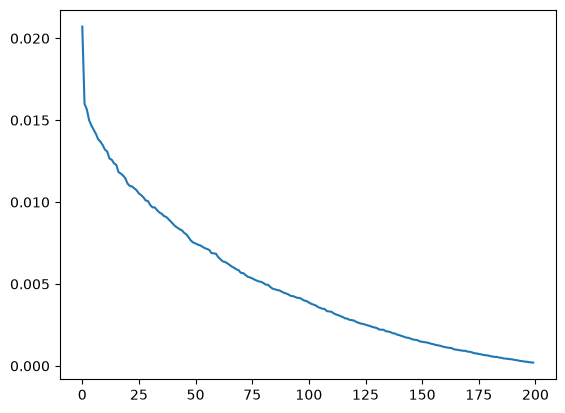

In [6]:
# Full PCA
pca = PCA(n_components=200)
full_pca_reducer = pca.fit(x198_train)
plt.plot(full_pca_reducer.explained_variance_ratio_)

**Comment:** their scree plots exhibit different shapes because the correlation matrix of the MNIST example has a lot of pair-wise correlation, suggesting PCA would be helpful; whereas the synthetic's correlation matrix has only one diagonal line, showing no indication that PCA would be helpful.

### Part C

In [11]:
cumulative_sum = np.cumsum(full_pca_reducer.explained_variance_ratio_)
n_90 = np.argmax(cumulative_sum >= 0.90) + 1
int(n_90)

121

### Part D

We know that PCA is sensitive to the scale of the input variables. However, all the predictors in the synthetic data were generated from normal distributions so there would not be any feature with a substantially large scale to dominate PCA. Thus, re-scaling is probably not necessary.

## Question 3

### Part A

In [ ]:
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.25, random_state=7)
pca_X2 = PCA(n_components=0.80)
pca_X2.fit(X2_train)
print("X2 number of retained principal components:", pca_X2.n_components_)

X48_train, X48_test, y48_train, y48_test = train_test_split(X48, y48, test_size=0.25, random_state=7)
pca_X48 = PCA(n_components=0.80)
pca_X48.fit(X48_train)
print("X48 number of retained principal components:", pca_X48.n_components_)

X198_train, X198_test, y198_train, y198_test = train_test_split(X198, y198, test_size=0.25, random_state=7)
pca_X198 = PCA(n_components=0.80)
pca_X198.fit(X198_train)
print("X198 number of retained principal components:", pca_X198.n_components_)

X2 number of retained principal components: 3
X48 number of retained principal components: 33
X198 number of retained principal components: 93


### Part B

In [16]:
knn = KNeighborsClassifier(n_neighbors=10)

# X2
knn.fit(X2_train, y2_train)
acc_original = accuracy_score(
    y2_test,
    knn.predict(X2_test)
)
knn.fit(pca_X2.transform(X2_train), y2_train)
acc_pca = accuracy_score(
    y2_test,
    knn.predict(pca_X2.transform(X2_test))
)
print(f"For X2, original accuracy score = {acc_original}, pca accuracy score = {acc_pca}")

# X48
knn.fit(X48_train, y48_train)
acc_original = accuracy_score(
    y48_test,
    knn.predict(X48_test)
)
knn.fit(pca_X48.transform(X48_train), y48_train)
acc_pca = accuracy_score(
    y48_test,
    knn.predict(pca_X48.transform(X48_test))
)
print(f"For X48, original accuracy score = {acc_original}, pca accuracy score = {acc_pca}")

# X198
knn.fit(X198_train, y198_train)
acc_original = accuracy_score(
    y198_test,
    knn.predict(X198_test)
)
knn.fit(pca_X198.transform(X198_train), y198_train)
acc_pca = accuracy_score(
    y198_test,
    knn.predict(pca_X198.transform(X198_test))
)
print(f"For X198, original accuracy score = {acc_original}, pca accuracy score = {acc_pca}")


For X2, original accuracy score = 0.93, pca accuracy score = 0.94
For X48, original accuracy score = 0.85, pca accuracy score = 0.91
For X198, original accuracy score = 0.77, pca accuracy score = 0.83


### Part C

PCA does seem to improve KNN classifier performance as noise increases. As more noise variables are added, the dimensionality of the original data increases, which can make distances less informative for KNN. PCA then reduces the dimensionality, which helps reduce the influence of noise and improves performance.

## Question 4

### Part A

In [17]:
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(mnist_train, label_train)
acc_mnist_original = accuracy_score(
    label_test,
    knn.predict(mnist_test)
)
acc_mnist_original

0.9341666666666667

### Part B

In [21]:
# PCA retaining 75%
mnist_pca = PCA(n_components=0.75)
mnist_train_pca = mnist_pca.fit_transform(mnist_train)
mnist_test_pca = mnist_pca.transform(mnist_test)
int(mnist_pca.n_components_)


33

### Part C

In [22]:
# KNN on PCA-transformed features
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(mnist_train_pca, label_train)
acc_mnist_pca = accuracy_score(
    label_test,
    knn.predict(mnist_test_pca)
)
acc_mnist_pca

0.95

### Part D

Part A and C tell us that with PCA, the improvement in accuracy score is from 93% to 95%. Part B tells us that PCA reduced the data from 784 pixel features down to 33 principal components while retaining 75% of the variance. Comparing this to Question 3 result, PCA seems to help the synthetic example more as noise increases. For MNIST, PCA also helped but for a different reason. When it comes to the structure of these data, since MNIST have many features correlated and contain possible redundancy, PCA would be better for MNIST.